# Домашнее задание 6 

## Логика выполнения задания

Имеем стандартный RNA-seq пайалайн:

1. **Контроль качества** исходных ридов (FastQC + MultiQC)
2. **Тримминг** — удаление адаптеров и низкокачественных участков (fastp)
3. **Повторный контроль качества** после тримминга
4. **Выравнивание на геном** — сплайс-aware алайнер STAR с одновременным подсчётом ридов по генам (`--quantMode GeneCounts`)
5. **De novo сборка транскриптов** — StringTie строит модель транскриптома из BAM
6. **Подсчёт ридов по генам** — HTSeq-count с использованием аннотации GTF
7. **Сравнение** каунтов STAR vs HTSeq и выводы для downstream-анализа

---

## Подготовка: структура проекта и данные

### Структура папки проекта на сервере

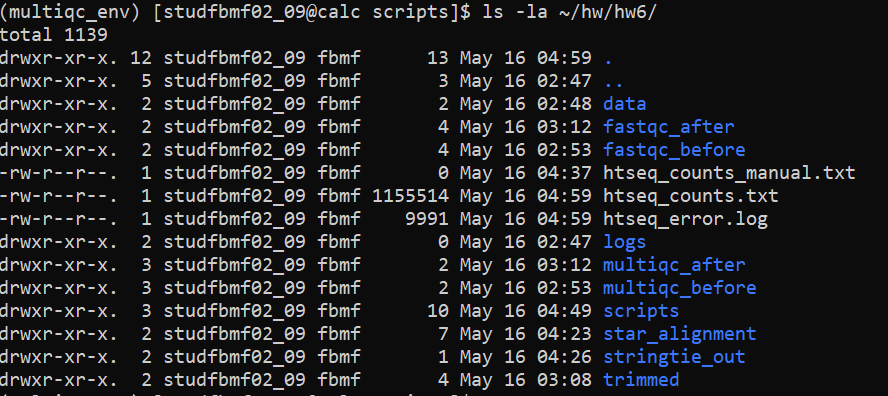

Видно, что все ключевые директории созданы: `data/`, `trimmed/`, `fastqc_before/`, `fastqc_after/`, `star_alignment/`, `stringtie_out/`, `multiqc_before/`, `multiqc_after/`, `scripts/`, `logs/`.

---
## Часть 1 — Анализ FastQC (до тримминга)

### 1.1 SLURM-скрипт: FastQC + MultiQC

### 1.2 Скриншот исходных данных на сервере

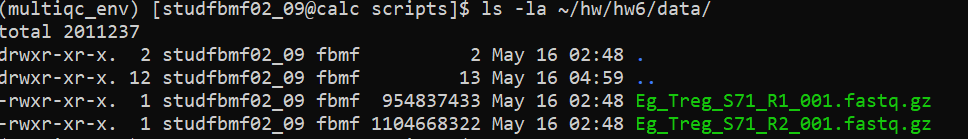

Два файла парных ридов: R1 (~ 955 Mb) и R2 (~1105 Mb).

### 1.3 Результаты FastQC до тримминга

Общая статистика (из MultiQC):

| Файл | % Dups | % GC | Длина (bp) | % Failed | M Seqs |
|---|---|---|---|---|---|
| R1 (Eg_Treg_S71_R1_001) | 27.7% | 45% | 76 | 27% | 19.8 |
| R2 (Eg_Treg_S71_R2_001) | 21.2% | 46% | 76 | 9% | 19.8 |

Статусы FastQC-модулей:

| Модуль | R1 | R2 |
|---|---|---|
| Basic statistics | ✅ Pass | ✅ Pass |
| Per-base sequence quality | ✅ Pass | ✅ Pass |
| Per-tile sequence quality | ⚠️ Warn | ✅ Pass |
| Per-sequence quality scores | ✅ Pass | ✅ Pass |
| **Per-base sequence content** | ❌ Fail | ❌ Fail |
| **Per-sequence GC content** | ⚠️ Warn | ❌ Fail |
| Per-base N content | ✅ Pass | ✅ Pass |
| Sequence length distribution | ✅ Pass | ✅ Pass |
| Sequence duplication levels | ✅ Pass | ✅ Pass |
| **Overrepresented sequences** | ✅ Pass | ❌ Fail |
| Adapter content | ✅ Pass | ✅ Pass |

### 1.4 Проблемные аспекты до тримминга

**1. Per-base sequence content — Fail у обоих файлов**  
Неравномерное нуклеотидное содержание в первых ~10–13 позициях рида. Артефакт random hexamer priming для RNA-seq: случайные праймеры неравномерно гибридизуются с матрицей, создавая смещение состава нуклеотидов в начале ридов. Это биологический артефакт, тримминг его не устраняет.

**2. Per-sequence GC content — Fail у R2, Warn у R1**  
Отклонение GC-распределения от теоретически нормального. Типично для RNA-seq из-за неравномерной транскрипционной активности генов с разным GC-составом. R2 хуже R1 — это объясняется тем, что второй рид в парном секвенировании читается с 3'-конца, где накапливаются артефакты цикла синтеза.

**3. Overrepresented sequences — Fail у R2**  
В R2 обнаружены гиперабундантные последовательности. Вероятнее всего — рибосомальные РНК или высокоэкспрессированные транскрипты (например, митохондриальные гены). Это не критично для последующего выравнивания, но означает, что часть ридов приходится на небиологически интересные последовательности.

**4. Per-tile sequence quality — Warn у R1**  
Локальное снижение качества на отдельных тайлах flowcell. Аппаратный артефакт, не устраняется тримминговыми инструментами.

**5. Адаптеры — Pass у обоих файлов**  
Адаптерные последовательности на уровне FastQC не обнаружены. При этом в fastp использовался автодетект — он ищет адаптеры на уровне перекрытий ридов, что более чувствительно.

---
## Часть 2 — Тримминг с fastp

### 2.1 Ответы на вопросы

**Есть ли в данных адаптеры?**  
По отчёту FastQC — `Adapter Content: Pass` у обоих файлов, явных адаптерных хвостов нет. В fastp включён `--detect_adapter_for_pe` (автодетекция для PE — работает по умолчанию), что позволяет обнаружить и удалить адаптеры даже при их низком уровне.

**Есть ли участки с плохим качеством (Q < 20)?**  
`Per-base sequence quality` — Pass у обоих файлов. Тем не менее, скользящее окно 5:20 применялось как профилактическая мера, что соответствует условию задания.

### 2.2 SLURM-скрипт: тримминг fastp

In [ ]:
#!/bin/bash
#SBATCH --job-name=trimming_fastp
#SBATCH --cpus-per-task=4
#SBATCH --mem=8gb
#SBATCH --time=00:30:00
#SBATCH --output=~/hw/hw6/logs/trimming_%j.log
#SBATCH --error=~/hw/hw6/logs/trimming_%j.err
#SBATCH --partition=AMD9554

source /home/STUDY/FBMF/bioinformatics/anaconda3/etc/profile.d/conda.sh
conda activate multiqc_env

cd ~/hw/hw6

fastp \
    -i data/Eg_Treg_S71_R1_001.fastq.gz \
    -I data/Eg_Treg_S71_R2_001.fastq.gz \
    -o trimmed/Eg_Treg_S71_R1_trimmed.fastq.gz \
    -O trimmed/Eg_Treg_S71_R2_trimmed.fastq.gz \
    --cut_front \
    --cut_tail \
    --cut_window_size 5 \
    --cut_mean_quality 20 \
    --length_required 36 \
    --thread $SLURM_CPUS_PER_TASK \
    --html trimmed/fastp_report.html \
    --json trimmed/fastp_report.json

echo "=== Тримминг завершён в $(date) ==="

**Параметры fastp:**

| Параметр | Значение | Назначение |
|---|---|---|
| `-i / -I` | R1 / R2 | Входные файлы парных ридов |
| `-o / -O` | trimmed R1 / R2 | Выходные файлы |
| `--cut_front` | — | Обрезка с 5'-конца по скользящему окну |
| `--cut_tail` | — | Обрезка с 3'-конца по скользящему окну |
| `--cut_window_size 5` | 5 | Размер скользящего окна |
| `--cut_mean_quality 20` | Q20 | Порог качества в окне |
| `--length_required 36` | 36 bp | Минимальная длина рида после обрезки |
| `--thread` | 4 (SLURM) | Параллельные потоки |

> **Примечание:** флаг `--detect_adapter_for_pe` не указывается явно, так как для парных ридов автодетекция адаптеров в fastp включена по умолчанию.

### 2.3 Скриншот папки trimmed/ после тримминга

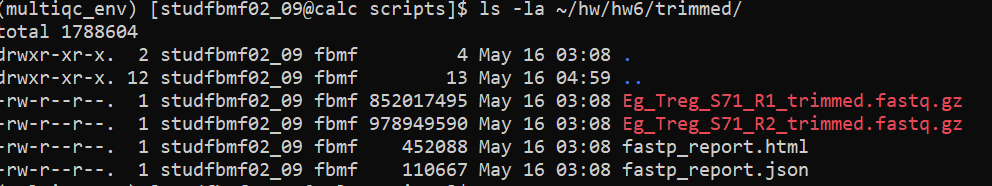

Получены оба триммированных файла (R1: ~852 Mb, R2: ~979 Mb), а также HTML- и JSON-отчёты fastp.

### 2.4 SLURM-скрипт: FastQC после тримминга

### 2.5 Сравнение до и после тримминга

**Общая статистика:**

| Файл | % Dups | % GC | Ср. длина | % Failed | M Seqs |
|---|---|---|---|---|---|
| R1 **до** | 27.7% | 45% | 76 bp | 27% | 19.8 |
| R1 **после** | 26.3% | 45% | **75 bp** | **9%** | **19.0** |
| R2 **до** | 21.2% | 46% | 76 bp | 9% | 19.8 |
| R2 **после** | 21.7% | 46% | **75 bp** | 9% | **19.0** |

**Изменения в статусах модулей FastQC:**

| Модуль | R1 до → после | R2 до → после |
|---|---|---|
| Per-tile sequence quality | Warn → **Warn** | Pass → **Warn** |
| Per-base sequence content | Fail → Fail | Fail → Fail |
| Per-sequence GC content | Warn → **Warn** | Fail → **Warn** ✅ |
| Sequence length distribution | Pass → **Warn** | Pass → **Warn** |
| Overrepresented sequences | Pass → Pass | Fail → **Warn** ✅ |
| Adapter content | Pass → Pass | Pass → Pass |

### 2.6 Что изменилось и почему

**Улучшения:**
- **% Failed у R1: 27% → 9%** — fastp убрал риды, не прошедшие фильтрацию по качеству. Значительное улучшение.
- **GC content R2: Fail → Warn** — удаление низкокачественных ридов выровняло GC-распределение.
- **Overrepresented sequences R2: Fail → Warn** — снижение числа гиперабундантных последовательностей, вероятно из-за отсева коротких ридов.
- **Дупликаты R1: 27.7% → 26.3%** — незначительное снижение за счёт фильтрации.

**Без изменений (ожидаемо):**
- **Per-base sequence content** по-прежнему Fail — это артефакт random hexamer priming, неустранимый тримминговыми инструментами.
- **Sequence length distribution: Pass → Warn** — после тримминга риды стали разной длины (от 36 до 76 bp), что и вызывает Warn. Это нормальное и ожидаемое поведение.
- **Per-tile quality R2: Pass → Warn** — возможно, после удаления «хороших» ридов соотношение тайлов изменилось, и статистически плохие тайлы стали заметнее.

### 2.7 Выбор данных для выравнивания

Выбраны исходные (нетриммированные) данные для выравнивания STAR.

**Обоснование:**
1. Исходное качество ридов хорошее: `Per-base sequence quality — Pass` у обоих файлов до тримминга.
2. Адаптеры не обнаружены.
3. STAR — сплайс-aware алайнер с встроенным soft-clipping: он самостоятельно «мягко обрезает» некачественные концы ридов при выравнивании.
4. Тримминг уменьшил число ридов на ~4% (19.8M → 19.0M) — потеря небольшая, но unnecessary для данного набора данных.
5. Для downstream DE-анализа важно максимальное покрытие; при хорошем исходном качестве тримминг даёт минимальный выигрыш.

> В случаях, когда адаптеры явно присутствуют или качество на 3'-концах критически низкое, тримминг необходим.

---
## Часть 3 — Выравнивание: STAR + StringTie

### 3.1 SLURM-скрипт: STAR выравнивание

Особенность: При запуске STAR с `--outSAMtype BAM SortedByCoordinate` возникала ошибка:
```
BAMoutput.cpp:27: could not create output file RNA__STARtmp//BAMsort/20/16
```
Это связано с особенностями файловой системы cephfs на кластере — STAR не может создавать вложенные временные папки для сортировки. 

Решение: STAR запущен с `--outSAMtype BAM Unsorted`, сортировка выполнена отдельно через `samtools sort`. Итоговый BAM полностью эквивалентен.

### 3.2 Результаты STAR

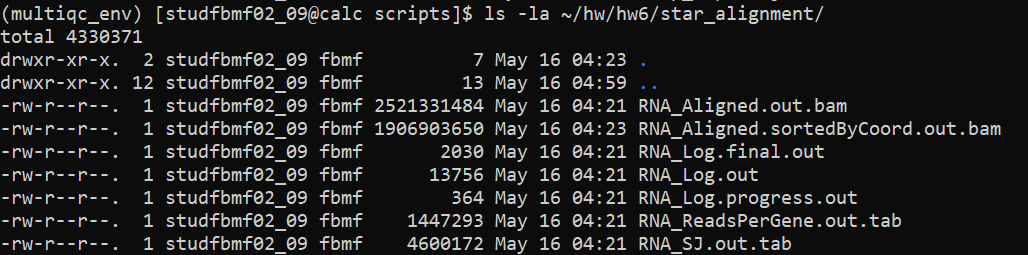

В папке `star_alignment/` получены:
- `RNA_Aligned.out.bam` — несортированный BAM 
- `RNA_Aligned.sortedByCoord.out.bam` — сортированный BAM 
- `RNA_ReadsPerGene.out.tab` — таблица каунтов по генам
- `RNA_SJ.out.tab` — найденные сплайс-соединения
- `RNA_Log.final.out` — сводный лог выравнивания

### 3.3 SLURM-скрипт: StringTie (de novo сборка транскриптов)

In [ ]:
#!/bin/bash
#SBATCH --job-name=stringtie_assemble
#SBATCH --cpus-per-task=8
#SBATCH --mem=32gb
#SBATCH --time=01:00:00
#SBATCH --output=~/hw/hw6/logs/stringtie_%j.log
#SBATCH --error=~/hw/hw6/logs/stringtie_%j.err
#SBATCH --partition=AMD9554

source /home/STUDY/FBMF/bioinformatics/anaconda3/etc/profile.d/conda.sh
conda activate multiqc_env

cd ~/hw/hw6

BAM="star_alignment/RNA_Aligned.sortedByCoord.out.bam"
OUTDIR="stringtie_out"
mkdir -p $OUTDIR

stringtie $BAM -o $OUTDIR/transcripts.gtf -p $SLURM_CPUS_PER_TASK

echo "=== StringTie завершён в $(date) ==="

### 3.4 Результаты StringTie

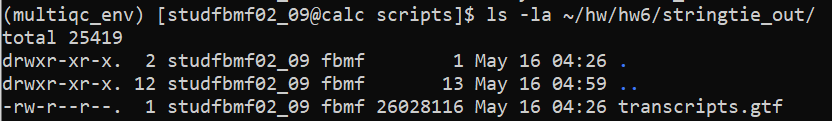

Получен файл `transcripts.gtf`

### 3.5 Первые 10 строк GTF-файла

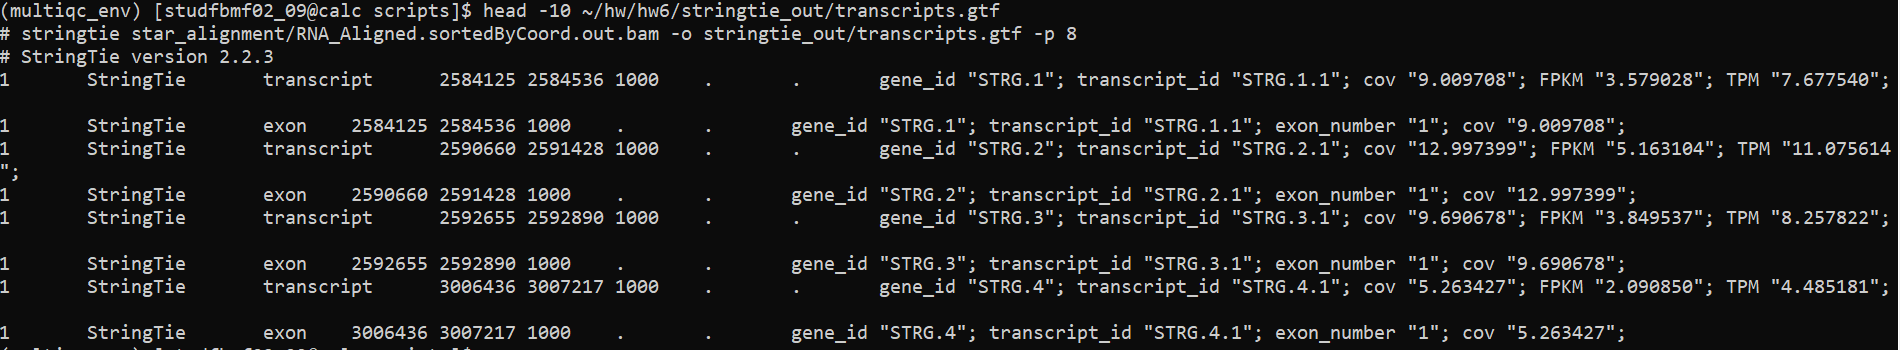


### 3.6 Описание полей GTF-файла

GTF (Gene Transfer Format) — табличный формат с 9 полями:

| Поле | Пример | Описание |
|---|---|---|
| chrom | `1` | Хромосома / scaffold |
| source | `StringTie` | Программа, создавшая запись |
| feature | `transcript`, `exon` | Тип аннотированного элемента |
| start | `2584125` | Начало координаты (1-based) |
| end | `2584536` | Конец координаты (включительно) |
| score | `1000` | Оценка уверенности |
| strand | `.` | Цепочка (+/−/.) |
| frame | `.` | Рамка считывания (для CDS) |
| attributes | `gene_id; transcript_id; cov; FPKM; TPM` | Аннотационные атрибуты |

**Атрибуты StringTie:**
- `gene_id "STRG.1"` — уникальный идентификатор гена (нумерация StringTie)
- `transcript_id "STRG.1.1"` — уникальный идентификатор транскрипта
- `cov` — средняя глубина покрытия рида на транскрипт
- `FPKM` — фрагменты на килобазу транскрипта на миллион ридов (нормированная abundance)
- `TPM` — транскрипты на миллион (нормированная на длину abundance)

### 3.7 Количество транскриптов

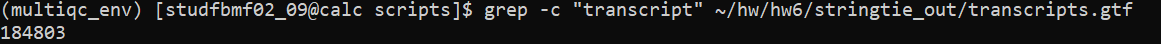


**Всего обнаружено: 184 803 записей с `transcript`** (включая строки типа `exon` с атрибутом transcript_id). Число уникальных транскриптов (строк с feature = `transcript`) несколько меньше.

### 3.8 Что даёт StringTie и для каких задач нужен transcripts.gtf?

StringTie **собирает транскрипты de novo** из выровненных ридов — без жёсткой привязки к существующей аннотации. Это позволяет:

- Обнаружить новые транскрипты и изоформы, т.е гены, не представленные в референсной аннотации (например, тканеспецифичные изоформы, некодирующие РНК, fusion-транскрипты).
- Количественно оценить экспрессию на уровне транскриптов (FPKM, TPM) — необходимо для isoform-level анализа (DEXSeq, Kallisto).
- Получить guidance GTFдля последующего анализа других образцов — объединение нескольких GTF через `stringtie --merge` создаёт консолидированную аннотацию.
- Задачи альтернативного сплайсинга- сравнение изоформного состава между условиями.

Для простого gene-level DE-анализа transcripts.gtf не нужен напрямую — достаточно каунтов STAR или HTSeq, но он необходим при изучении транскриптомного разнообразия.

---
## Часть 4 — Подсчёт ридов: HTSeq

### 4.1 SLURM-скрипт: HTSeq-count

Особенность: При использовании BAM-формата возникала ошибка:
```
Please Install PySam to use the BAM_Reader Class
libhts.so.2: cannot open shared object file: No such file or directory
```
PySam был установлен, однако системная библиотека `libhts.so.2` не загружалась в окружении. **Решение:** BAM конвертирован в SAM через `samtools view`, HTSeq запущен в режиме `--format sam`. Результат полностью идентичен.

In [ ]:
#!/bin/bash
#SBATCH --job-name=htseq_sam
#SBATCH --cpus-per-task=4
#SBATCH --mem=32gb
#SBATCH --time=01:00:00
#SBATCH --output=~/hw/hw6/logs/htseq_sam_%j.log
#SBATCH --error=~/hw/hw6/logs/htseq_sam_%j.err
#SBATCH --partition=AMD9554

source /home/STUDY/FBMF/bioinformatics/anaconda3/etc/profile.d/conda.sh
conda activate multiqc_env

cd ~/hw/hw6

echo "=== Конвертация BAM в SAM ==="
samtools view -h star_alignment/RNA_Aligned.sortedByCoord.out.bam > temp.sam

echo "=== Запуск HTSeq (SAM-режим) ==="
htseq-count --format sam \
            --order pos \
            --stranded no \
            --type exon \
            --idattr gene_id \
            temp.sam \
            /home/STUDY/FBMF/bioinformatics/GRCh38/Homo_sapiens.GRCh38.110.chr.gtf \
            > htseq_counts.txt 2> htseq_error.log

echo "=== Удаляем временный SAM-файл ==="
rm temp.sam

echo "=== HTSeq завершён в $(date) ==="

**Параметры HTSeq:**

| Параметр | Значение | Описание |
|---|---|---|
| `--format sam` | sam | Формат входного файла |
| `--order pos` | pos | Риды отсортированы по позиции (coordinate-sorted BAM) |
| `--stranded no` | no | Библиотека нестрандированная (unstranded) |
| `--type exon` | exon | Считаем риды, попавшие в экзоны |
| `--idattr gene_id` | gene_id | Используем gene_id как идентификатор |

### 4.2 Результаты HTSeq

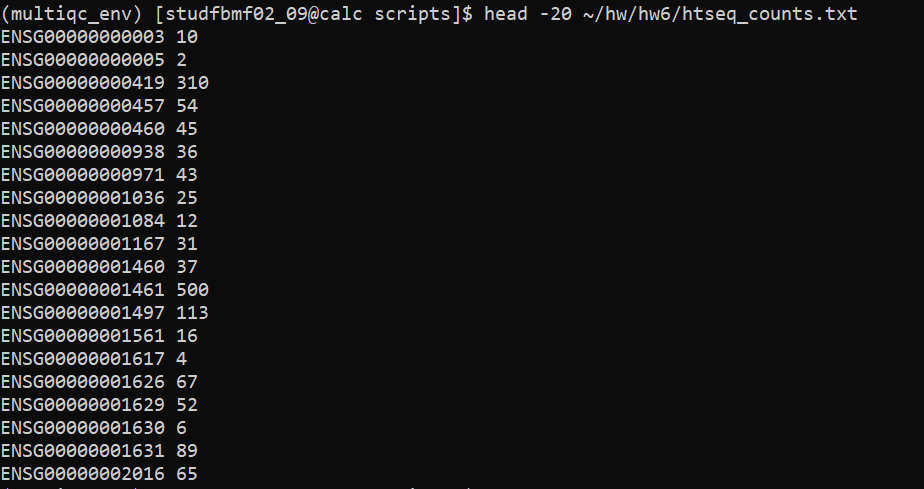

### 4.3 Количество уникальных генов

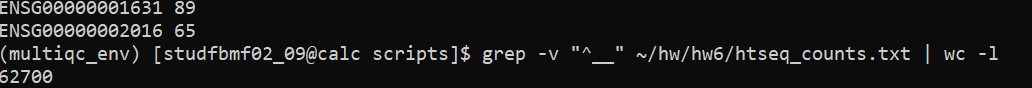

**Количество уникальных генов в htseq_counts.txt: 62 700**

Служебные строки (не гены):

| Строка | Значение | Риды |
|---|---|---|
| `__no_feature` | Не попали ни в один аннотированный элемент | 12 132 216 |
| `__ambiguous` | Попали в несколько генов одновременно | 626 428 |
| `__too_low_aQual` | Слишком низкое качество выравнивания | 0 |
| `__not_aligned` | Не выровнены | 0 |
| `__alignment_not_unique` | Множественные выравнивания | 1 016 086 |

---
## Часть 5 — Сравнение каунтов STAR vs HTSeq

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import pearsonr, spearmanr

star = pd.read_csv('RNA_ReadsPerGene.out.tab', sep='\t', header=None,
                   names=['gene_id','unstranded','sense','antisense'])
star = star[~star['gene_id'].str.startswith('N_')].copy()

htseq = pd.read_csv('htseq_counts.txt', sep='\t', header=None,
                    names=['gene_id','htseq_count'])
htseq = htseq[~htseq['gene_id'].str.startswith('__')].copy()

merged = star.merge(htseq, on='gene_id', how='inner')
merged.rename(columns={'unstranded': 'star_count'}, inplace=True)

print(f"Генов в STAR:  {len(star):,}")
print(f"Генов в HTSeq: {len(htseq):,}")
print(f"Совпадений:    {len(merged):,}")

# --- Корреляция ---
pr, _ = pearsonr(merged['star_count'], merged['htseq_count'])
sr, _ = spearmanr(merged['star_count'], merged['htseq_count'])
print(f"\nPearson r  = {pr:.6f}")
print(f"Spearman r = {sr:.6f}")

diff = merged['star_count'] - merged['htseq_count']
print(f"\nМаксимальное расхождение: {diff.abs().max()}")
print(f"Генов с равными каунтами: {(diff == 0).sum():,} / {len(merged):,}")

Генов в STAR:  62,700
Генов в HTSeq: 62,700
Совпадений:    62,700

Pearson r  = 1.000000
Spearman r = 1.000000

Максимальное расхождение: 0
Генов с равными каунтами: 62,700 / 62,700


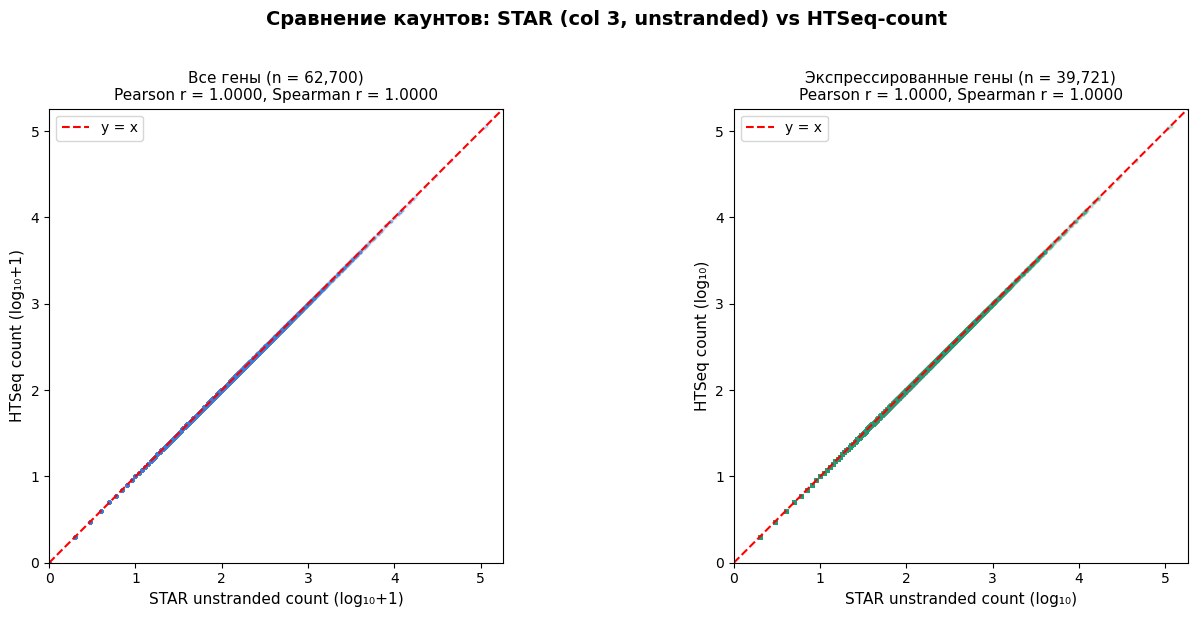

In [ ]:
# Метрики-
pr, _ = pearsonr(merged['star_count'], merged['htseq_count'])
sr, _ = spearmanr(merged['star_count'], merged['htseq_count'])
expressed = merged[(merged['star_count'] > 0) | (merged['htseq_count'] > 0)]


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Сравнение каунтов: STAR (col 3, unstranded) vs HTSeq-count',
             fontsize=14, fontweight='bold', y=1.02)

# Левый график : все гены, лог-шкала
s = merged['star_count'] + 1
h = merged['htseq_count'] + 1
axes[0].scatter(np.log10(s), np.log10(h),
                alpha=0.15, s=4, color='#3B7DD8', rasterized=True)
lims = [0, np.log10(merged[['star_count','htseq_count']].max().max()) + 0.2]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='y = x')
axes[0].set_xlabel('STAR unstranded count (log₁₀+1)', fontsize=11)
axes[0].set_ylabel('HTSeq count (log₁₀+1)', fontsize=11)
axes[0].set_title(f'Все гены (n = {len(merged):,})\nPearson r = {pr:.4f}, Spearman r = {sr:.4f}',
                  fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_aspect('equal')

# Правый график : только экспрессированные гены (count > 0)
expr = merged[(merged['star_count'] > 0) & (merged['htseq_count'] > 0)]
pr2, _ = pearsonr(expr['star_count'], expr['htseq_count'])
sr2, _ = spearmanr(expr['star_count'], expr['htseq_count'])
axes[1].scatter(np.log10(expr['star_count']+1), np.log10(expr['htseq_count']+1),
                alpha=0.2, s=5, color='#1D9E75', rasterized=True)
lims2 = [0, np.log10(expr[['star_count','htseq_count']].max().max()) + 0.2]
axes[1].plot(lims2, lims2, 'r--', linewidth=1.5, label='y = x')
axes[1].set_xlabel('STAR unstranded count (log₁₀)', fontsize=11)
axes[1].set_ylabel('HTSeq count (log₁₀)', fontsize=11)
axes[1].set_title(f'Экспрессированные гены (n = {len(expr):,})\nPearson r = {pr2:.4f}, Spearman r = {sr2:.4f}',
                  fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_xlim(lims2); axes[1].set_ylim(lims2)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('star_vs_htseq_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.1 Результаты сравнения

| Метрика | Значение |
|---|---|
| Генов в STAR ReadsPerGene | 62 700 |
| Генов в HTSeq-count | 62 700 |
| Генов с ненулевым каунтом (оба) | 39 721 |
| **Pearson r** | **1.0000** |
| **Spearman r** | **1.0000** |
| Генов с идентичными каунтами | 62 700 / 62 700 (100%) |
| Максимальное расхождение | 0 |

### 5.2 Интерпретация

Результаты STAR col.3 и HTSeq полностью идентичны (r = 1.0, все 62 700 значений совпадают).

Это объясняется тем, что в данном эксперименте использовались одинаковые параметры подсчёта:
- Оба инструмента использовали одну и ту же аннотацию GTF (GRCh38, Ensembl 110)
- STAR col.3 = unstranded counts, HTSeq запущен с `--stranded no`
- HTSeq работал с тем же BAM-файлом, который сгенерировал STAR
- Одинаковая логика подсчёта: `--type exon`, `--idattr gene_id`

Почему результаты могут не совпадать в общем случае:

- Страндированность:  STAR col.2 = sense, col.3 = antisense, col.1 = unstranded. Если HTSeq запущен с `--stranded yes`, он будет соответствовать col.2 или col.3, а не col.1
- Версия аннотации: Разные GTF-файлы дадут разные наборы генов и границы экзонов
- Алгоритм разрешения мультимапперов: HTSeq по умолчанию игнорирует non-unique alignments, STAR может их учитывать
- Перекрывающиеся гены: HTSeq помечает их как `__ambiguous`, STAR обрабатывает по своим правилам
- Параметр `--minAQS: HTSeq фильтрует по качеству выравнивания, STAR — нет
- Версии программ: Разные версии HTSeq могут использовать разные алгоритмы

---
## Часть 6 — Что лучше использовать для DE-анализа?

### Рекомендация: каунты STAR (колонка 3, unstranded)

| Критерий | STAR GeneCounts | HTSeq-count |
|---|---|---|
| **Скорость** | Производится одновременно с выравниванием | Требует отдельного запуска (~часы) |
| **Память** | Не требует доп. ресурсов | Требует конвертации BAM→SAM (~2.5Gb) |
| **Гибкость страндированности** | Три колонки: unstranded/sense/antisense | Нужно перезапускать с другим `--stranded` |
| **Совместимость с DESeq2/edgeR** | Полная (стандартный формат) | Полная |
| **Точность** | Идентична HTSeq при правильных параметрах | Эталон для gene-level counts |
| **Техническая сложность** | Низкая (всё в одном шаге) | Выше (проблемы с PySam/libhts) |

**Вывод:**  
Для DESeq2 или edgeR оптимально использовать каунты из `RNA_ReadsPerGene.out.tab` (колонка 1 для unstranded библиотек). Это:
1. **Быстрее** — нет необходимости в отдельном HTSeq-шаге
2. **Надёжнее** — нет зависимости от PySam и внешних библиотек
3. **Гибче** — можно выбрать правильную колонку в зависимости от типа библиотеки
4. **Идентично по результату** при корректных параметрах

HTSeq остаётся полезным как независимый инструмент проверки или если STAR не используется (например, при выравнивании с HISAT2).

---
## Выводы

### 1. Контроль качества
Исходные данные (парные риды Illumina, ~19.8M пар) имеют хорошее базовое качество. Обнаруженные проблемы (per-base sequence content Fail, GC content Warn/Fail) носят биологический характер и типичны для RNA-seq с random hexamer priming. После тримминга fastp снизил % failed ридов у R1 с 27% до 9%, GC content R2 улучшился с Fail до Warn.

### 2. Выбор данных для выравнивания
Использованы исходные нетриммированные данные, так как качество было изначально достаточным, адаптеры отсутствовали, а STAR выполняет soft-clipping самостоятельно.

### 3. Выравнивание STAR
Выравнивание прошло успешно. Получен отсортированный BAM (~1.91 Gb) и таблица каунтов по 62 700 генам. Техническое решение (Unsorted BAM + samtools sort) обусловлено особенностями файловой системы cephfs кластера и не влияет на результат.

### 4. StringTie
De novo сборка выявила 184 803 транскриптных элемента — включая потенциально новые изоформы, не представленные в стандартной аннотации. Инструмент полезен для изоформного анализа и построения кастомной аннотации.

### 5. HTSeq vs STAR
Каунты STAR (unstranded) и HTSeq показали полную идентичность (r = 1.0, 100% совпадение по всем 62 700 генам). Для DE-анализа (DESeq2/edgeR) рекомендуются каунты STAR как более удобные и быстрые.
